In [1]:
from FastBEMT.Propeller import Propeller
from FastBEMT.JobParameters import LowFidelityParameters
from FastBEMT.DataLoader import *
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'no-latex'])

In [3]:
blade_dict = load_propeller_dict('run_001/Pareto1')

In [4]:
params = LowFidelityParameters(
    rpm=7000,
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
    n_blades=blade_dict['n_blades'],
    p_ref=2e-5,
    revolutions=5,
    num_obs_times_per_rev=100,
    device='cuda'
)

In [5]:
nx, ny = 26, 26
size = 5

In [6]:
x_range = np.linspace(-size, size, nx)
y_range = np.linspace(0, size, ny)
X, Y = np.meshgrid(x_range, y_range)
Z = np.zeros_like(X) 

r_observers = np.stack([X.flatten(), Y.flatten(), Z.flatten()], axis=1)

propeller = Propeller(
    geometry=blade_dict,
    params=params,
)

propeller.run_bemt(v_inf=0.0)

In [7]:
propeller.run_aeroacoustics(observer_positions=r_observers,
        lt=1,
        i=1e-3,
        alpha_stall=15,
        keep_bpm_components=False)

[CUDA TIMING] TorchCompactAcousticSourceArray.__init__: 350.470 ms
[CUDA TIMING] BPM.__init__: 1.091 ms
[CUDA TIMING] get_observer_times: 74.489 ms
[CUDA TIMING] calculate_f1a_pressure: 296.588 ms
[CUDA TIMING] combine_sources (F1A): 101.059 ms
[CUDA TIMING] _perform_spectral_analysis_torch: 504.202 ms
[CUDA TIMING] BPM.run_forward_bpm: 943.131 ms
[CUDA TIMING] combine_sources_bpm: 11.617 ms


In [8]:
propeller.postprocess()

In [9]:
propeller.third_octave_total_oaspl = propeller.third_octave_total_oaspl.reshape(ny, nx)

# Mirror the computed data to show both sides (symmetric around x=0)
# Flip all rows and stack with original, excluding the center row to avoid duplication
propeller.third_octave_total_oaspl_full = np.vstack([
    propeller.third_octave_total_oaspl[::-1, :],     # Flip for negative y
    propeller.third_octave_total_oaspl[1:, :]        # Original positive y, skip y=0 to avoid duplication
])

In [10]:
from FastBEMT.Stress import BladeStressCalculator

stress_calc = BladeStressCalculator(propeller=propeller)

In [11]:
def load_data(filepath, channel):
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    t = data['sound']['channels'][str(channel)]['time']
    p = data['sound']['channels'][str(channel)]['pressure']
    fs = 1.0 / np.mean(np.diff(t))
    return t, p, fs


def extract_propeller_noise(p_total, p_motor, fs, nperseg=1024, alpha=1.0, beta=0.1):
    f, t, Zxx_total = scipy.signal.stft(p_total, fs=fs, nperseg=nperseg)
    _, _, Zxx_motor = scipy.signal.stft(p_motor, fs=fs, nperseg=nperseg)

    mag_total = np.abs(Zxx_total)
    phase_total = np.angle(Zxx_total)
    mag_motor_avg = np.mean(np.abs(Zxx_motor), axis=1, keepdims=True)

    mag_prop = np.maximum(mag_total - (alpha * mag_motor_avg), beta * mag_motor_avg)
    
    Zxx_prop = mag_prop * np.exp(1j * phase_total)
    t_final, p_prop_only = scipy.signal.istft(Zxx_prop, fs=fs)
    
    return t_final, p_prop_only

In [12]:
def calc_oaspl_np(spl_array, freqs, weighted=False):
    """Calculates OSPL or A-weighted OASPL."""
    valid_mask = np.isfinite(spl_array)
    spl = spl_array[valid_mask]
    f = freqs[valid_mask]
    
    if len(spl) == 0: return 0
    
    if weighted:
        a_offsets = get_a_weighting_np(f)
        spl = spl + a_offsets
        
    return 10 * np.log10(np.sum(10**(spl / 10)))

In [13]:
def get_a_weighting_np(f):
    """Calculate A-weighting offset in dB for a given frequency f."""
    ra = lambda f: (12194**2 * f**4) / (
        (f**2 + 20.6**2) * np.sqrt((f**2 + 107.7**2) * (f**2 + 737.9**2)) * (f**2 + 12194**2)
    )
    return 20 * np.log10(ra(f)) - 20 * np.log10(ra(1000))

In [14]:
# import pyfar as pf
# import scipy
# res = []

# f_low = propeller.third_octave_freqs.cpu().numpy() / (2 ** (1 / 6))
# f_high = propeller.third_octave_freqs.cpu().numpy() * (2 ** (1 / 6))

# for channel in range(1,11):
#     print('channel')
#     t_total, p_total, fs_total = load_data('../Datasets/Measurements/10x7e_2024-11-28-13-14-55_RPM_7000.pkl', channel=channel)
#     t_motor, p_motor, fs_motor = load_data('../Datasets/Background/Background_2024-11-28-12-56-35_RPM_7000.pkl', channel=channel)
#     t_final, p_prop_only = extract_propeller_noise(p_total, p_motor, fs_total)
#     fs = 1 / (t_final[1] - t_final[0])
#     signal = pf.Signal(p_prop_only, fs, fft_norm='rms')
#     clean_frequencies = signal.frequencies[np.newaxis, ...]
#     clean_spl = pf.dsp.decibel(signal, domain='freq', log_reference=2e-5).T

#     mask = (clean_frequencies >= f_low[..., np.newaxis]) & \
#         (clean_frequencies <= f_high[..., np.newaxis])

#     # 4. Convert SPL to Power
#     p_raw = 10 ** (clean_spl / 10)
#     p_band = mask @ p_raw
#     clean_spl_3oct = 10 * np.log10(p_band)
#     clean_spl_3oct[p_band == 0] = -np.inf
#     clean_ospl_exp = calc_oaspl_np(clean_spl_3oct.squeeze(), propeller.third_octave_freqs.cpu().numpy(), weighted=True)
#     res.append(clean_ospl_exp)


In [15]:
r_observers = 1.88 * np.array([
    [0.050,  0.000, -0.999], # Position 1
    [0.150, -0.856,  0.494], # Position 2
    [0.250,  0.839,  0.484], # Position 3
    [0.350,  0.811, -0.468], # Position 4
    [0.450, -0.773, -0.447], # Position 5
    [0.550,  0.000,  0.835], # Position 6
    [0.650,  0.658,  0.380], # Position 7
    [0.750,  0.000, -0.661], # Position 8
    [0.850, -0.456,  0.263], # Position 9
    [0.950,  0.000,  0.312]  # Position 10
])

X_obs = r_observers[:, 0]
Y_obs = (r_observers[:, 1]**2 + r_observers[:, 2]**2)**0.5

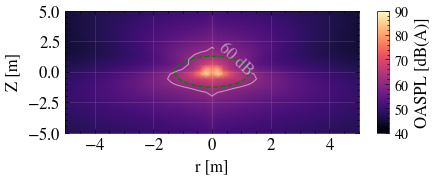

In [17]:
fig, ax = plt.subplots(figsize=(4.5, 2))

vmin = np.floor(propeller.third_octave_total_oaspl_full.min() / 10) * 10
vmax = np.ceil(propeller.third_octave_total_oaspl_full.max() / 10) * 10

# Create full grid for plotting
x_range_plot = np.linspace(-size, size, nx)
y_range_plot = np.linspace(-size, size, 2*ny - 1)
X_plot, Y_plot = np.meshgrid(x_range_plot, y_range_plot)

smooth_levels = np.linspace(vmin, vmax, 1000)
cf = ax.contourf(Y_plot, X_plot, propeller.third_octave_total_oaspl_full, levels=smooth_levels, cmap='magma')
im = ax.pcolormesh(Y_plot, X_plot, propeller.third_octave_total_oaspl_full, cmap='magma', 
                   vmin=vmin, vmax=vmax, shading='gouraud', zorder=1)

cbar = fig.colorbar(im, ax=ax, shrink=1, aspect=10, pad=0.05, ticks=np.arange(vmin, vmax + 10, 10))

cbar.set_label('OASPL [dB(A)]', fontsize=12)
cbar.ax.tick_params(labelsize=10)

angles = np.linspace(-np.pi, np.pi, 100)
r = 10*propeller.geometry['tip_radius']
ax.plot(r*np.cos(angles), r*np.sin(angles), '--', c='g', linewidth=1)

line_levels = [60]
label_coords = [(2.0, 2.0), (2.0, 1.0), (2.0, 3.0), (2.0, 3.0), (2.0, 3.0), (2.0, 3.0)] 

for level, coord in zip(line_levels, label_coords):
    cntr = ax.contour(Y_plot, X_plot, propeller.third_octave_total_oaspl_full, levels=[level], colors='white', 
                      linewidths=0.8, alpha=0.5)
    ax.clabel(cntr, inline=True, fontsize=12, fmt='%1.0f dB', manual=[coord])

ax.set_xlabel('r [m]', fontsize=12)
ax.set_ylabel('Z [m]', fontsize=12)

ax.grid(True, alpha=0.15, color='white')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('Figures/acoustic_map.pdf', dpi=200)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, box
from typing import Any

def compute_weighted_oaspl_contour_area(
    propeller: Any,
    target_level: float,
    weight_below: float,
) -> float:
    """
    Compute the weighted area where OASPL >= target_level, 
    clipped to the data boundaries and split at x = 0.
    """
    if (propeller.third_octave_total_oaspl_full is None 
        or propeller.observer_positions is None):
        raise ValueError("Data not initialized.")

    x_range_plot = np.linspace(-size, size, nx)
    y_range_plot = np.linspace(-size, size, 2*ny - 1)
    x_vals, y_vals = np.meshgrid(x_range_plot, y_range_plot)
    z_grid = propeller.third_octave_total_oaspl_full

    # 2. Define Bounding Boxes for Clipping
    x_min, x_max = x_vals.min(), x_vals.max()
    y_min, y_max = y_vals.min(), y_vals.max()
    
    # Box for x < 0 and x >= 0
    # Note: box(minx, miny, maxx, maxy)
    bottom_half_box = box(x_min, y_min, 0.0, y_max)
    top_half_box = box(0.0, y_min, x_max, y_max)

    # 3. Extract Filled Contours
    # We use levels=[target_level, max_val] to get the area "inside" the contour
    max_val = max(z_grid.max(), target_level + 1)
    fig, ax = plt.subplots()
    contour_set = ax.contourf(Y_plot, X_plot, z_grid, levels=[target_level, max_val])
    # plt.close(fig) # Prevent ghost plots in memory¨
    plt.show()

    area_above = 0.0
    area_below = 0.0

    # 4. Process Geometry
    # contourf returns a list of collections; we look at the first one (our target level)
    for path in contour_set.get_paths():
        # Convert paths to Shapely polygons
        # Each path might have multiple 'polygons' (islands or holes)
        for coords in path.to_polygons():
            if len(coords) < 3:
                continue
            
            poly = Polygon(coords)
            if not poly.is_valid:
                poly = poly.buffer(0)

            # Clip the polygon to our split boxes
            poly_below = poly.intersection(bottom_half_box)
            poly_above = poly.intersection(top_half_box)

            area_below += poly_below.area
            area_above += poly_above.area

    # 5. Calculate Final Weighted Metric
    weighted_area = (area_below * weight_below) + area_above
    
    return weighted_area

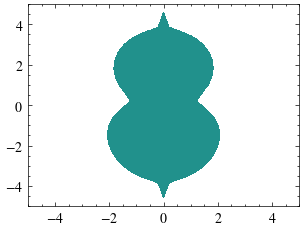

73.02086553076701

In [ ]:
compute_weighted_oaspl_contour_area(propeller, 60, 5)